In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
# Load baselines
baselines = joblib.load('../models/baselines.joblib')

# Load all window data
windows_01 = pd.read_csv('../data/windows_cow01.csv')
windows_03 = pd.read_csv('../data/windows_cow03.csv')
windows_04 = pd.read_csv('../data/windows_cow04.csv')

# Load twin history (has anomaly scores and states)
twin_history = pd.read_csv('../data/twin_cow04_history.csv')
twin_history['timestamp'] = pd.to_datetime(twin_history['timestamp'])

# Load scored cow04 data
cow04_scored = pd.read_csv('../data/cow04_scored.csv')
cow04_scored['window_start'] = pd.to_datetime(cow04_scored['window_start'])

print("All data loaded")
print(f"Twin history: {len(twin_history):,} records")

All data loaded
Twin history: 16,867 records


In [3]:
# Simulate states for cow_01 and cow_03
# In a real system these would be live
# For dashboard we use their baseline profiles

herd_summary = pd.DataFrame([
    {
        'Animal ID':       'cow_01',
        'Role':            'Training',
        'Days Monitored':  17,
        'Eating %':        baselines['cow_01']['eating_pct'],
        'Ruminating %':    baselines['cow_01']['ruminating_pct'],
        'Other %':         baselines['cow_01']['other_pct'],
        'Health State':    'NORMAL',
        'Anomaly Windows': 'N/A (baseline animal)',
    },
    {
        'Animal ID':       'cow_03',
        'Role':            'Training',
        'Days Monitored':  13,
        'Eating %':        baselines['cow_03']['eating_pct'],
        'Ruminating %':    baselines['cow_03']['ruminating_pct'],
        'Other %':         baselines['cow_03']['other_pct'],
        'Health State':    'NORMAL',
        'Anomaly Windows': 'N/A (baseline animal)',
    },
    {
        'Animal ID':       'cow_04',
        'Role':            'Monitored (test)',
        'Days Monitored':  6,
        'Eating %':        baselines['cow_04']['eating_pct'],
        'Ruminating %':    baselines['cow_04']['ruminating_pct'],
        'Other %':         baselines['cow_04']['other_pct'],
        'Health State':    twin_history['state'].iloc[-1],
        'Anomaly Windows': f"{twin_history['is_anomaly'].sum():,} / {len(twin_history):,} (14.7%)",
    },
])

print(herd_summary.to_string(index=False))

Animal ID             Role  Days Monitored  Eating %  Ruminating %  Other % Health State        Anomaly Windows
   cow_01         Training              17     19.34         40.14    40.52       NORMAL  N/A (baseline animal)
   cow_03         Training              13     21.16         37.19    41.66       NORMAL  N/A (baseline animal)
   cow_04 Monitored (test)               6     17.10         36.26    46.63       NORMAL 2,481 / 16,867 (14.7%)


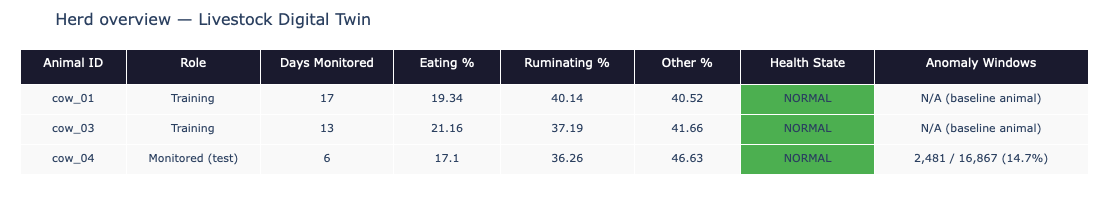

Herd overview saved


In [4]:
state_colors = {
    'NORMAL': '#4CAF50',
    'AT_RISK': '#FF9800', 
    'ALERT': '#F44336',
    'N/A (baseline animal)': '#9E9E9E'
}

cell_colors = [
    ['#f9f9f9'] * 3,
    ['#f9f9f9'] * 3,
    ['#f9f9f9'] * 3,
    ['#f9f9f9'] * 3,
    ['#f9f9f9'] * 3,
    ['#f9f9f9'] * 3,
    [state_colors[s] for s in herd_summary['Health State']],
    ['#f9f9f9'] * 3,
]

fig_table = go.Figure(data=[go.Table(
    columnwidth=[80, 100, 100, 80, 100, 80, 100, 160],
    header=dict(
        values=list(herd_summary.columns),
        fill_color='#1a1a2e',
        font=dict(color='white', size=12),
        align='center',
        height=35
    ),
    cells=dict(
        values=[herd_summary[col] for col in herd_summary.columns],
        fill_color=cell_colors,
        align='center',
        font=dict(size=11),
        height=30
    )
)])

fig_table.update_layout(
    title='Herd overview — Livestock Digital Twin',
    title_font_size=16,
    margin=dict(l=20, r=20, t=50, b=20),
    height=200
)

fig_table.show()
fig_table.write_html('../dashboard/herd_overview.html')
print("Herd overview saved")

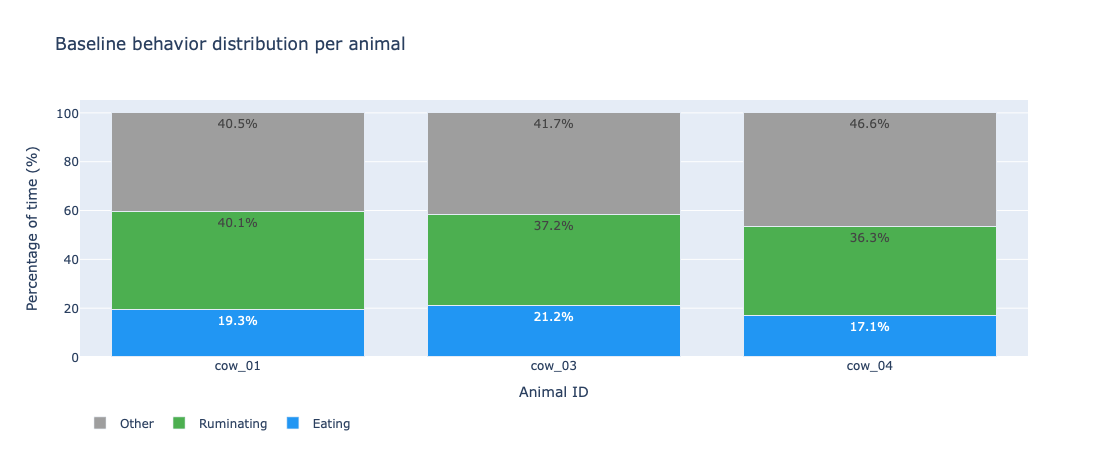

Behavior distribution saved


In [5]:
animals    = ['cow_01', 'cow_03', 'cow_04']
eating     = [baselines[a]['eating_pct']     for a in animals]
ruminating = [baselines[a]['ruminating_pct'] for a in animals]
other      = [baselines[a]['other_pct']      for a in animals]

fig_behavior = go.Figure()

fig_behavior.add_trace(go.Bar(
    name='Eating',
    x=animals, y=eating,
    marker_color='#2196F3',
    text=[f'{v:.1f}%' for v in eating],
    textposition='inside'
))

fig_behavior.add_trace(go.Bar(
    name='Ruminating',
    x=animals, y=ruminating,
    marker_color='#4CAF50',
    text=[f'{v:.1f}%' for v in ruminating],
    textposition='inside'
))

fig_behavior.add_trace(go.Bar(
    name='Other',
    x=animals, y=other,
    marker_color='#9E9E9E',
    text=[f'{v:.1f}%' for v in other],
    textposition='inside'
))

fig_behavior.update_layout(
    barmode='stack',
    title='Baseline behavior distribution per animal',
    yaxis_title='Percentage of time (%)',
    xaxis_title='Animal ID',
    legend=dict(orientation='h', y=-0.2),
    height=450
)

fig_behavior.show()
fig_behavior.write_html('../dashboard/behavior_distribution.html')
print("Behavior distribution saved")

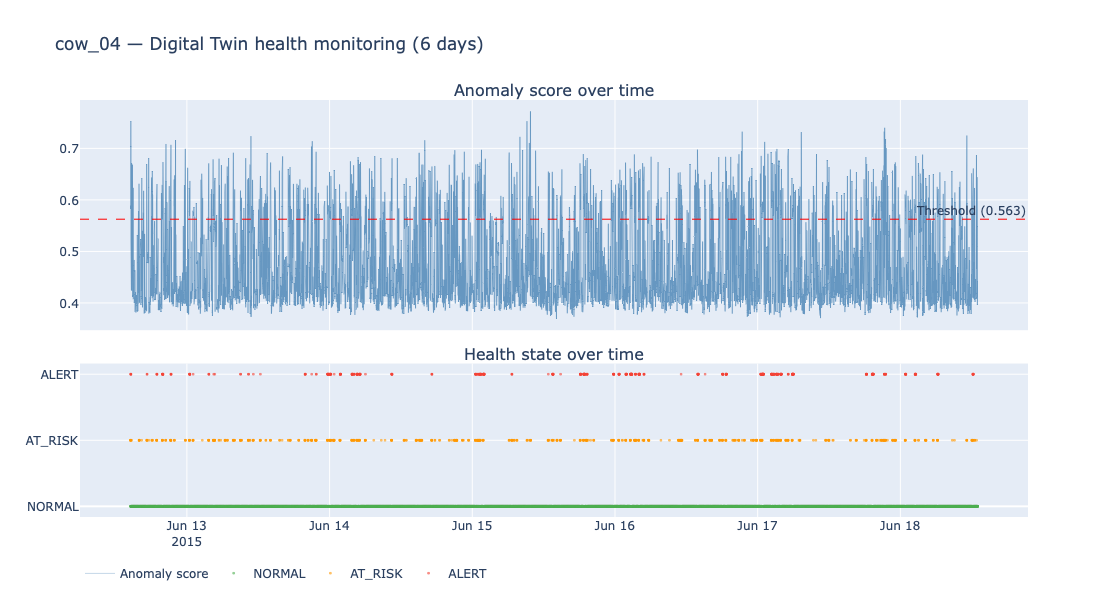

Anomaly timeline saved


In [6]:
fig_anomaly = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('Anomaly score over time', 'Health state over time'),
    row_heights=[0.6, 0.4],
    vertical_spacing=0.08
)

# Anomaly score line
fig_anomaly.add_trace(
    go.Scatter(
        x=twin_history['timestamp'],
        y=twin_history['anomaly_score'],
        mode='lines',
        name='Anomaly score',
        line=dict(color='steelblue', width=0.8),
        opacity=0.8
    ), row=1, col=1
)

# Threshold line
threshold = cow04_scored[cow04_scored['is_anomaly']==1]['anomaly_score'].min()
fig_anomaly.add_hline(
    y=threshold, line_dash='dash',
    line_color='red', line_width=1,
    annotation_text=f'Threshold ({threshold:.3f})',
    row=1, col=1
)

# Health state colored scatter
state_color_map = {'NORMAL': '#4CAF50', 'AT_RISK': '#FF9800', 'ALERT': '#F44336'}
state_num_map   = {'NORMAL': 0, 'AT_RISK': 1, 'ALERT': 2}

for state, color in state_color_map.items():
    mask = twin_history['state'] == state
    fig_anomaly.add_trace(
        go.Scatter(
            x=twin_history[mask]['timestamp'],
            y=twin_history[mask]['state'].map(state_num_map),
            mode='markers',
            name=state,
            marker=dict(color=color, size=3, opacity=0.6),
        ), row=2, col=1
    )

fig_anomaly.update_yaxes(
    tickvals=[0, 1, 2],
    ticktext=['NORMAL', 'AT_RISK', 'ALERT'],
    row=2, col=1
)

fig_anomaly.update_layout(
    title='cow_04 — Digital Twin health monitoring (6 days)',
    height=600,
    showlegend=True,
    legend=dict(orientation='h', y=-0.1)
)

fig_anomaly.show()
fig_anomaly.write_html('../dashboard/anomaly_timeline.html')
print("Anomaly timeline saved")

In [7]:
# Extract all AT_RISK and ALERT events
alerts = twin_history[twin_history['state'].isin(['AT_RISK', 'ALERT'])].copy()
alerts = alerts[['timestamp', 'state', 'anomaly_score', 
                  'anomaly_streak', 'predicted_behavior']].reset_index(drop=True)

print(f"=== Alert Log — cow_04 ===")
print(f"Total AT_RISK events: {(twin_history['state']=='AT_RISK').sum():,}")
print(f"Total ALERT events:   {(twin_history['state']=='ALERT').sum():,}")
print(f"\nFirst 10 alerts:")
print(alerts.head(10).to_string(index=False))

# Save alert log
alerts.to_csv('../dashboard/alert_log.csv', index=False)
print("\nAlert log saved to ../dashboard/alert_log.csv")

=== Alert Log — cow_04 ===
Total AT_RISK events: 711
Total ALERT events:   582

First 10 alerts:
          timestamp   state  anomaly_score  anomaly_streak predicted_behavior
2015-06-12 14:31:02 AT_RISK       0.582504               3              Other
2015-06-12 14:31:32 AT_RISK       0.588874               4              Other
2015-06-12 14:32:03 AT_RISK       0.588330               5              Other
2015-06-12 14:32:33 AT_RISK       0.586082               6              Other
2015-06-12 14:33:04 AT_RISK       0.586740               7              Other
2015-06-12 14:33:34   ALERT       0.585155               8              Other
2015-06-12 14:34:04   ALERT       0.741240               9             Eating
2015-06-12 14:34:35   ALERT       0.752596              10             Eating
2015-06-12 14:35:05   ALERT       0.703008              11             Eating
2015-06-12 14:42:41 AT_RISK       0.639633               3             Eating

Alert log saved to ../dashboard/alert_log.cs

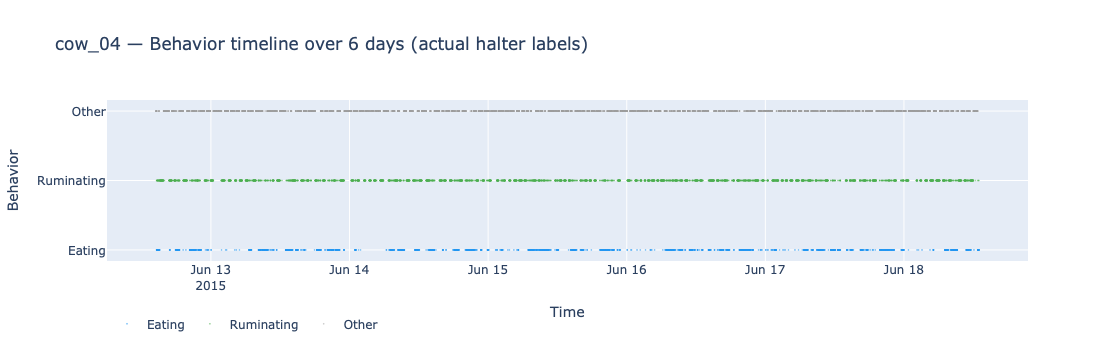

Behavior timeline saved


In [8]:
cow04_scored['window_start'] = pd.to_datetime(cow04_scored['window_start'])

behavior_color_map = {
    'Eating':     '#2196F3',
    'Ruminating': '#4CAF50',
    'Other':      '#9E9E9E'
}

fig_behavior_time = go.Figure()

for behavior, color in behavior_color_map.items():
    mask = cow04_scored['behavior'] == behavior
    fig_behavior_time.add_trace(go.Scatter(
        x=cow04_scored[mask]['window_start'],
        y=cow04_scored[mask]['behavior'],
        mode='markers',
        name=behavior,
        marker=dict(color=color, size=2, opacity=0.5)
    ))

fig_behavior_time.update_layout(
    title='cow_04 — Behavior timeline over 6 days (actual halter labels)',
    xaxis_title='Time',
    yaxis_title='Behavior',
    height=350,
    legend=dict(orientation='h', y=-0.3)
)

fig_behavior_time.show()
fig_behavior_time.write_html('../dashboard/behavior_timeline.html')
print("Behavior timeline saved")

In [9]:
from plotly.subplots import make_subplots
import plotly.io as pio

# Write a single HTML file that loads all charts
html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Livestock Digital Twin Dashboard</title>
    <style>
        body {{ font-family: Arial, sans-serif; 
                background: #f4f4f4; margin: 20px; }}
        h1   {{ color: #1a1a2e; text-align: center; }}
        h2   {{ color: #444; margin-top: 30px; }}
        .card {{ background: white; border-radius: 8px; 
                 padding: 20px; margin-bottom: 20px;
                 box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
    </style>
</head>
<body>
    <h1>Livestock Health Digital Twin — Dashboard</h1>
    <p style="text-align:center;color:#666">
        UK Precision Beef Dataset · 3 Animals · Easter Howgate Farm
    </p>

    <div class="card">
        <h2>Herd Overview</h2>
        {table}
    </div>

    <div class="card">
        <h2>Baseline Behavior Distribution</h2>
        {behavior}
    </div>

    <div class="card">
        <h2>cow_04 — Anomaly Detection Timeline</h2>
        {anomaly}
    </div>

    <div class="card">
        <h2>cow_04 — Behavior Timeline</h2>
        {behavior_time}
    </div>

</body>
</html>
"""

# Get HTML div for each figure
table_div         = pio.to_html(fig_table,          full_html=False)
behavior_div      = pio.to_html(fig_behavior,        full_html=False)
anomaly_div       = pio.to_html(fig_anomaly,         full_html=False)
behavior_time_div = pio.to_html(fig_behavior_time,   full_html=False)

final_html = html_content.format(
    table=table_div,
    behavior=behavior_div,
    anomaly=anomaly_div,
    behavior_time=behavior_time_div
)

with open('../dashboard/dashboard.html', 'w') as f:
    f.write(final_html)

print("Full dashboard saved to ../dashboard/dashboard.html")
print("Open this file in your browser to view the complete dashboard")

Full dashboard saved to ../dashboard/dashboard.html
Open this file in your browser to view the complete dashboard


In [10]:
print("=== Alert Summary Statistics ===\n")

# Duration of longest alert streak
max_streak = alerts['anomaly_streak'].max()
max_streak_time = alerts.loc[alerts['anomaly_streak'].idxmax(), 'timestamp']
print(f"Longest alert streak:  {max_streak} consecutive windows")
print(f"  = {max_streak * 0.5:.0f} minutes of sustained anomaly")
print(f"  Occurred at: {max_streak_time}")

# Which behavior dominates during alerts
print(f"\nBehavior during alert events:")
behavior_dist = alerts['predicted_behavior'].value_counts()
for b, count in behavior_dist.items():
    print(f"  {b:12s}: {count:5,} ({count/len(alerts)*100:.1f}%)")

# Alert distribution by day
print(f"\nAlerts by day:")
alerts['date'] = pd.to_datetime(alerts['timestamp']).dt.date
daily = alerts.groupby(['date', 'state']).size().unstack(fill_value=0)
print(daily.to_string())

# Highest anomaly score recorded
top5 = alerts.nlargest(5, 'anomaly_score')[
    ['timestamp', 'state', 'anomaly_score', 'predicted_behavior']]
print(f"\nTop 5 highest anomaly scores:")
print(top5.to_string(index=False))

=== Alert Summary Statistics ===

Longest alert streak:  37 consecutive windows
  = 18 minutes of sustained anomaly
  Occurred at: 2015-06-16 02:50:55

Behavior during alert events:
  Other       :   967 (74.8%)
  Eating      :   325 (25.1%)
  Ruminating  :     1 (0.1%)

Alerts by day:
state       ALERT  AT_RISK
date                      
2015-06-12     24       48
2015-06-13     43      116
2015-06-14     79      123
2015-06-15    115      112
2015-06-16    111      139
2015-06-17    167      127
2015-06-18     43       46

Top 5 highest anomaly scores:
          timestamp   state  anomaly_score predicted_behavior
2015-06-15 09:48:56 AT_RISK       0.760101             Eating
2015-06-12 14:34:35   ALERT       0.752596             Eating
2015-06-12 14:34:04   ALERT       0.741240             Eating
2015-06-15 09:11:56 AT_RISK       0.736720             Eating
2015-06-17 21:16:23 AT_RISK       0.732322             Eating


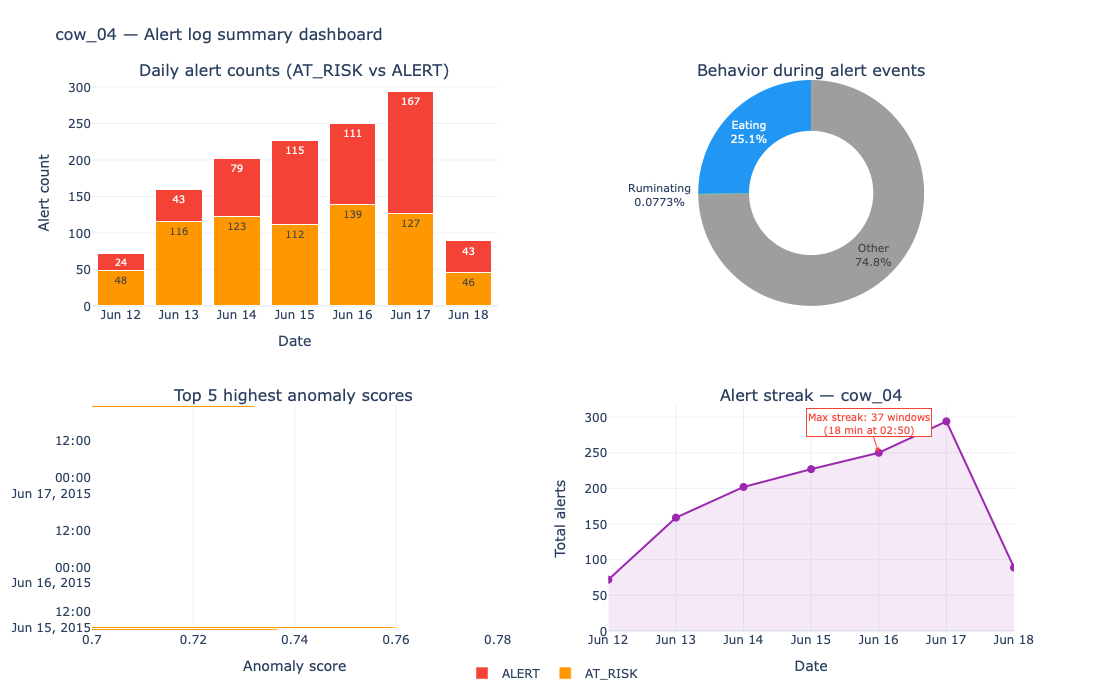

Saved to ../dashboard/alert_summary_dashboard.html
